Saving bleach.png to bleach (1).png


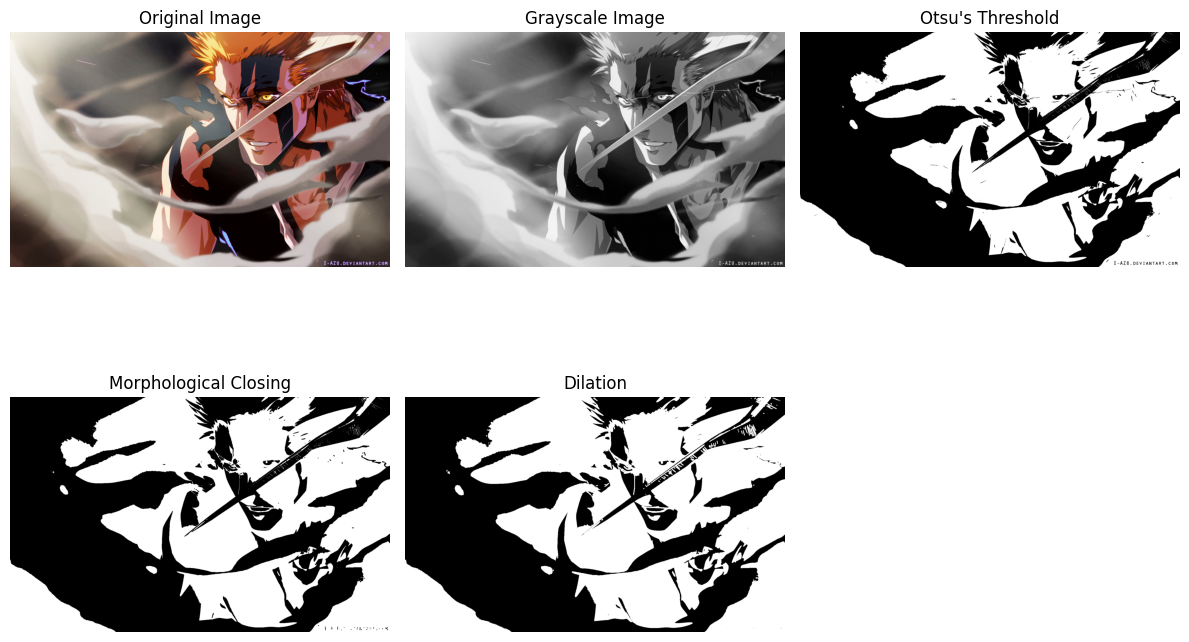

Image segmentation completed successfully.
Dilation result saved as: dilation.png


In [7]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from google.colab import files

# Upload image from computer
uploaded = files.upload()

# Get uploaded image filename
filename = next(iter(uploaded))

# Read image
img = cv2.imread(filename)

# Check if image was loaded successfully
if img is None:
    print("Error: Could not load the image.")
else:
    # Convert BGR to RGB
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Otsu's thresholding
    ret, thresh = cv2.threshold(
        gray, 0, 255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # Create kernel
    kernel = np.ones((2, 2), np.uint8)

    # Apply morphological closing
    closing = cv2.morphologyEx(
        thresh,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Apply dilation
    sure_bg = cv2.dilate(
        closing,
        kernel,
        iterations=3
    )

    # Display results
    plt.figure(figsize=(12, 8))

    plt.subplot(231)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(232)
    plt.imshow(gray, cmap="gray")
    plt.title("Grayscale Image")
    plt.axis("off")

    plt.subplot(233)
    plt.imshow(thresh, cmap="gray")
    plt.title("Otsu's Threshold")
    plt.axis("off")

    plt.subplot(234)
    plt.imshow(closing, cmap="gray")
    plt.title("Morphological Closing")
    plt.axis("off")

    plt.subplot(235)
    plt.imshow(sure_bg, cmap="gray")
    plt.title("Dilation")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # Save dilation result
    plt.imsave("dilation.png", sure_bg, cmap="gray")

    print("Image segmentation completed successfully.")
    print("Dilation result saved as: dilation.png")